# TEST TECHNIQUE – TRAITEMENT DU LANGAGE NATUREL (NLP)
## Classification de commentaires citoyens sur les services publics
**Projet** : Sélection des participants de TAISS 2026 pour un stage chez Afriklang / Togo AI Lab  
**Candidat** : NAMESSI Mazama-Esso  
**Date** : Octobre 2026

---
## Partie 1 — Exploration & Prétraitement des données
### 1.1 Chargement et exploration des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Configuration graphique
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# 1. Chargement du dataset
df = pd.read_csv('dataset_nlp_test_tal.csv')

print(f"Structure du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.\n")
print("Aperçu des 5 premières lignes :")
display(df.head())

print("\nInformations sur les types et valeurs manquantes :")
df.info()

Structure du dataset : 150 lignes et 3 colonnes.

Aperçu des 5 premières lignes :


,id,texte,categorie
0,1,Manque total de communication entre les services.,Insatisfaction
1,2,Il serait bien de proposer des tutoriels vidéo...,Suggestion
2,3,Envoyer des SMS de confirmation lors de chaque...,Suggestion
3,4,Prévoir des interprètes pour les citoyens ne p...,Suggestion
4,5,Le formulaire en ligne plante au moment de la ...,Insatisfaction



Informations sur les types et valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         150 non-null    int64 
 1   texte      150 non-null    object
 2   categorie  150 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.6+ KB


#### Visualisation de la distribution des classes et de la longueur des textes

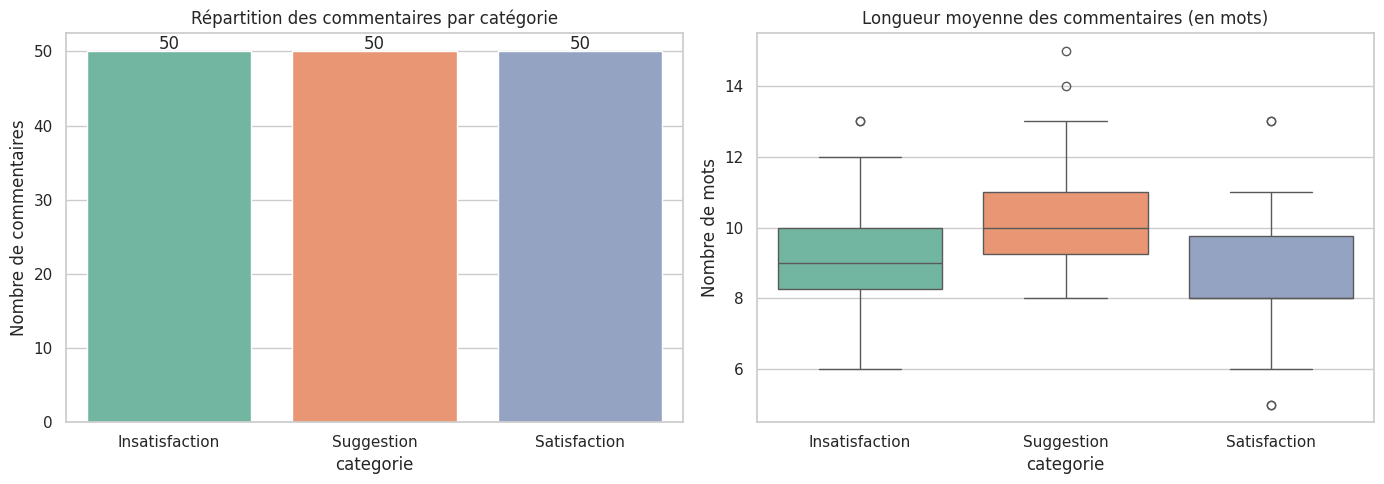


--- Statistique descriptive de la longueur par catégorie ---


word_length                   char_length                  
                      mean       std min max        mean       std min max
categorie                                                                 
Insatisfaction        9.34  1.636447   6  13       57.76  7.950253  34  78
Satisfaction          8.68  1.634326   5  13       57.40  8.334830  27  76
Suggestion           10.50  1.446318   8  15       69.82  5.321079  58  84

In [2]:
# Calcul de la longueur en mots et en caractères
df['char_length'] = df['texte'].apply(len)
df['word_length'] = df['texte'].apply(lambda x: len(x.split()))

# Visualisation 1 : Distribution des catégories
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='categorie', palette='Set2', ax=ax[0])
ax[0].set_title("Répartition des commentaires par catégorie")
ax[0].set_ylabel("Nombre de commentaires")

for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Visualisation 2 : Distribution de la longueur en mots par catégorie
sns.boxplot(data=df, x='categorie', y='word_length', palette='Set2', ax=ax[1])
ax[1].set_title("Longueur moyenne des commentaires (en mots)")
ax[1].set_ylabel("Nombre de mots")

plt.tight_layout()
plt.show()

print("\n--- Statistique descriptive de la longueur par catégorie ---")
display(df.groupby('categorie')[['word_length', 'char_length']].agg(['mean', 'std', 'min', 'max']))

### 1.2 Nettoyage et Prétraitement du texte

**Stratégie adoptée :**
1. **Mise en minuscules** et suppression des caractères spéciaux et chiffres.
2. **Gestion des mots en Éwé/Mina** : Analyse des occurrences locales (ex: *Akpe na wò*, *Yèvu service la nyuie hafi!*, *Mele via o, service la mègbe trop!*). Les termes régionaux comme `akpe` (merci), `nyuie` (bon), `mègbe` (en arrière/lent) sont préservés car ils véhiculent une polarité cruciale.
3. **Filtrage sélectif des Stopwords français** : Les mots vides standards sont supprimés, **à l'exception** des marqueurs de négation (`pas`, `non`, `ne`, `plus`, `sans`, `jamais`) et d'intensité (`très`, `trop`, `bien`) qui permettent de distinguer les plaintes (*Insatisfaction*) des recommandations (*Suggestion*).

In [3]:
# Liste explicite de stopwords français
FRENCH_STOPWORDS = set([
    'a', 'au', 'aux', 'avec', 'ce', 'ces', 'dans', 'de', 'des', 'du', 'elle', 'en', 'et', 'eux',
    'il', 'ils', 'je', 'la', 'le', 'les', 'leur', 'lui', 'ma', 'mais', 'me', 'même', 'mes', 'moi',
    'mon', 'nos', 'notre', 'nous', 'on', 'ou', 'par', 'pour', 'qu', 'que', 'qui', 'sa', 'se',
    'ses', 'son', 'sur', 'ta', 'te', 'tes', 'toi', 'ton', 'tu', 'un', 'une', 'vos', 'votre', 'vous',
    'c', 'd', 'j', 'l', 'à', 'm', 'n', 's', 't', 'y', 'été', 'étée', 'étées', 'étés', 'étant',
    'suis', 'es', 'est', 'sommes', 'êtes', 'sont', 'ai', 'as', 'avons', 'avez', 'ont'
])

# Préservation des mots clés pour la polarité et les langues locales (Éwé/Mina)
PRESERVED_WORDS = {'pas', 'non', 'ne', 'plus', 'jamais', 'rien', 'sans', 'trop', 'bien', 'très', 'tres', 'akpe', 'nyuie', 'mele', 'mègbe'}
CUSTOM_STOPWORDS = FRENCH_STOPWORDS - PRESERVED_WORDS

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zàâäéèêëîïôöùûüçɔɛŋ\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in CUSTOM_STOPWORDS and len(t) > 1]
    return " ".join(tokens)

df['clean_text'] = df['texte'].apply(clean_text)

print("Exemples de nettoyage :")
for i in [0, 7, 72, 130, 138]:
    print(f"ID {df.loc[i, 'id']} [{df.loc[i, 'categorie']}] :")
    print(f"  Original : {df.loc[i, 'texte']}")
    print(f"  Nettoyé  : {df.loc[i, 'clean_text']}\n")

Exemples de nettoyage :
ID 1 [Insatisfaction] :
  Original : Manque total de communication entre les services.
  Nettoyé  : manque total communication entre services

ID 8 [Satisfaction] :
  Original : J'ai été agréablement surpris par la rapidité du traitement.
  Nettoyé  : agréablement surpris rapidité traitement

ID 73 [Satisfaction] :
  Original : Yèvu service la nyuie hafi!
  Nettoyé  : yèvu service nyuie hafi

ID 131 [Insatisfaction] :
  Original : Mele via o, service la mègbe trop!
  Nettoyé  : mele via service mègbe trop

ID 139 [Satisfaction] :
  Original : Akpe na wò, service très professionnel et efficace.
  Nettoyé  : akpe na service très professionnel efficace



### 1.3 Visualisations : Nuages de mots et Fréquence des termes

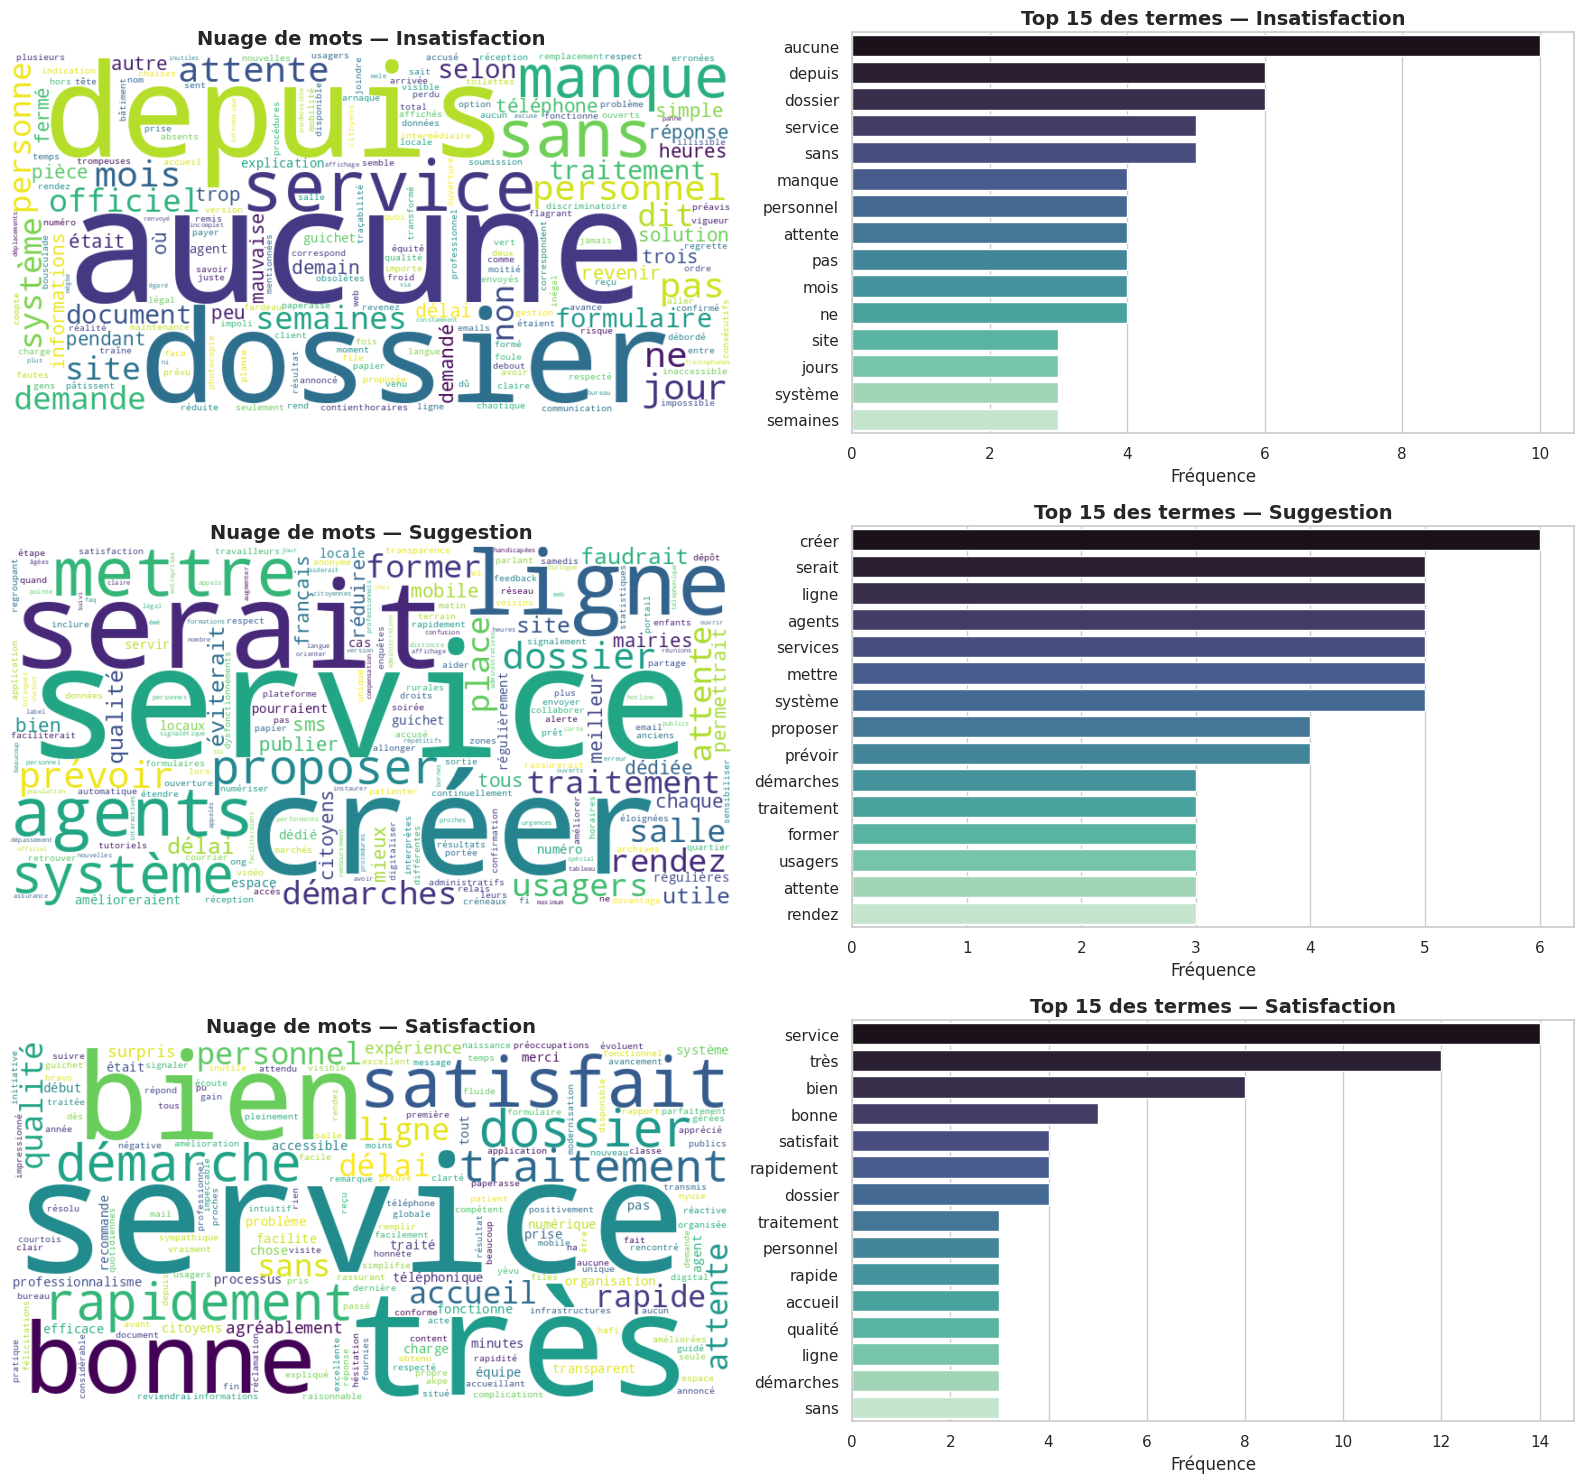

In [4]:
from wordcloud import WordCloud
from collections import Counter

categories = df['categorie'].unique()
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

for idx, cat in enumerate(categories):
    subset = df[df['categorie'] == cat]['clean_text']
    all_words = " ".join(subset).split()
    word_counts = Counter(all_words).most_common(15)

    # Nuage de mots
    wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(" ".join(subset))
    axes[idx, 0].imshow(wc, interpolation='bilinear')
    axes[idx, 0].axis('off')
    axes[idx, 0].set_title(f"Nuage de mots — {cat}", fontsize=14, fontweight='bold')

    # Barplot top 15 mots
    words, counts = zip(*word_counts)
    sns.barplot(x=list(counts), y=list(words), palette='mako', ax=axes[idx, 1])
    axes[idx, 1].set_title(f"Top 15 des termes — {cat}", fontsize=14, fontweight='bold')
    axes[idx, 1].set_xlabel("Fréquence")

plt.tight_layout()
plt.show()

---
## Partie 2 — Modélisation
### 2.1 Vectorisation & Train/Test Split

**Choix de vectorisation : TF-IDF (`TfidfVectorizer`) avec n-grammes (1, 2)**
* **Justification** : Le TF-IDF permet de pondérer l'importance relative des termes par rapport au corpus global. L'utilisation des bi-grammes permet de capturer les expressions clés composées (ex: *service rapide*, *pas accusé*, *file attente*).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split stratifié 80% Train / 20% Test
X_train, X_test, y_train, y_test, ids_train, ids_test, orig_train, orig_test = train_test_split(
    df['clean_text'], df['categorie'], df['id'], df['texte'],
    test_size=0.20, random_state=42, stratify=df['categorie']
)

# Vectorisation TF-IDF
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Taille du vocabulaire extrait : {len(vectorizer.get_feature_names_out())} termes/bi-grammes.")
print(f"Matrice d'entraînement : {X_train_vec.shape}")
print(f"Matrice de test : {X_test_vec.shape}")

Taille du vocabulaire extrait : 1000 termes/bi-grammes.
Matrice d'entraînement : (120, 1000)
Matrice de test : (30, 1000)


### 2.2 Entraînement et Comparaison de plusieurs Algorithmes

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (Linéaire)': SVC(kernel='linear', random_state=42, probability=True),
    'Régression Logistique': LogisticRegression(random_state=42, C=1.5),
    'Naive Bayes': MultinomialNB()
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'Algorithme': name, 'Accuracy': f"{acc:.4f}", 'F1-Score Macro': f"{f1:.4f}"})

summary_df = pd.DataFrame(results)
print("=== TABLEAU SYNTHÉTIQUE DES PERFORMANCES ===")
display(summary_df)

=== TABLEAU SYNTHÉTIQUE DES PERFORMANCES ===


,Algorithme,Accuracy,F1-Score Macro
0,Random Forest,0.7667,0.7556
1,SVM (Linéaire),0.7333,0.7368
2,Régression Logistique,0.7333,0.7363
3,Naive Bayes,0.7000,0.7033


### 2.3 Évaluation Détaillée et Matrices de Confusion

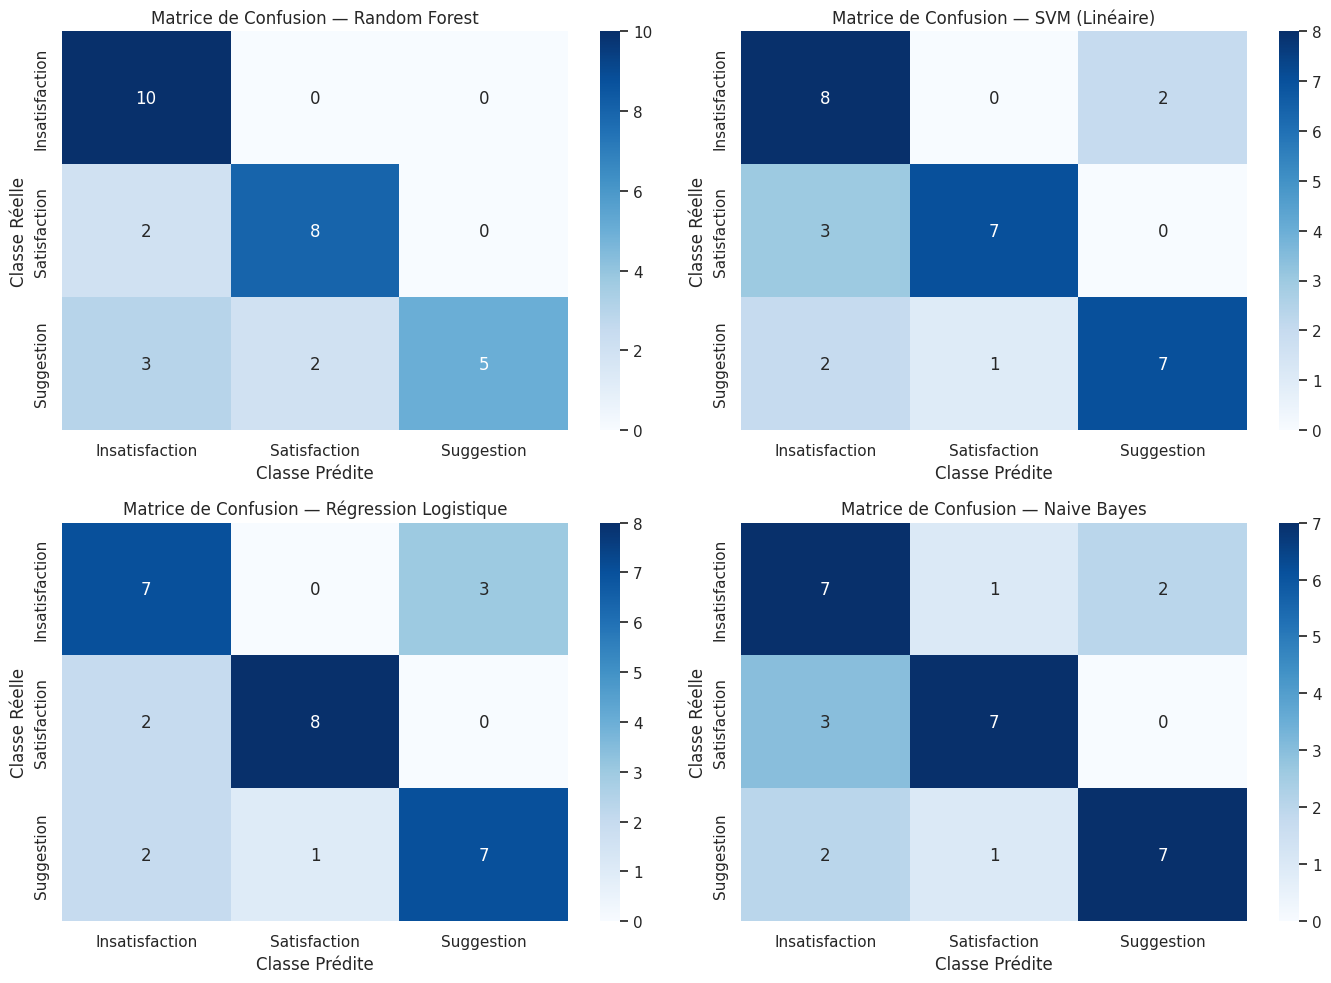


--- Rapport de classification détaillé du meilleur modèle (Random Forest) ---
                precision    recall  f1-score   support

Insatisfaction       0.67      1.00      0.80        10
  Satisfaction       0.80      0.80      0.80        10
    Suggestion       1.00      0.50      0.67        10

      accuracy                           0.77        30
     macro avg       0.82      0.77      0.76        30
  weighted avg       0.82      0.77      0.76        30



In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
cats = ['Insatisfaction', 'Satisfaction', 'Suggestion']

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=cats)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cats, yticklabels=cats, ax=axes[idx])
    axes[idx].set_title(f"Matrice de Confusion — {name}")
    axes[idx].set_xlabel("Classe Prédite")
    axes[idx].set_ylabel("Classe Réelle")

plt.tight_layout()
plt.show()

print("\n--- Rapport de classification détaillé du meilleur modèle (Random Forest) ---")
print(classification_report(y_test, predictions['Random Forest']))

### 2.4 Analyse Qualitative des Erreurs de Prédiction

In [8]:
best_preds = predictions['Random Forest']
test_analysis = pd.DataFrame({
    'id': ids_test,
    'texte_original': orig_test,
    'texte_nettoyé': X_test,
    'classe_réelle': y_test,
    'classe_prédite': best_preds
})

errors = test_analysis[test_analysis['classe_réelle'] != test_analysis['classe_prédite']]
print(f"Nombre d'erreurs identifiées sur le jeu de test : {len(errors)} / 30\n")

for idx, row in errors.iterrows():
    print(f"📌 ID {row['id']} |")
    print(f"   Texte original : \"{row['texte_original']}\"")
    print(f"   Texte nettoyé  : \"{row['texte_nettoyé']}\"")
    print(f"   Classe Réelle  : [ {row['classe_réelle']} ] <---> Classe Prédite : [ {row['classe_prédite']} ]\n")

Nombre d'erreurs identifiées sur le jeu de test : 7 / 30

📌 ID 20 |
   Texte original : "L'agent était patient et à l'écoute de mes préoccupations."
   Texte nettoyé  : "agent était patient écoute préoccupations"
   Classe Réelle  : [ Satisfaction ] <---> Classe Prédite : [ Insatisfaction ]

📌 ID 114 |
   Texte original : "Service numérique fonctionnel et accessible depuis mon téléphone."
   Texte nettoyé  : "service numérique fonctionnel accessible depuis téléphone"
   Classe Réelle  : [ Satisfaction ] <---> Classe Prédite : [ Insatisfaction ]

📌 ID 14 |
   Texte original : "Numériser les archives pour retrouver rapidement les anciens dossiers."
   Texte nettoyé  : "numériser archives retrouver rapidement anciens dossiers"
   Classe Réelle  : [ Suggestion ] <---> Classe Prédite : [ Satisfaction ]

📌 ID 107 |
   Texte original : "Des bornes interactives dans les mairies faciliteraient les démarches."
   Texte nettoyé  : "bornes interactives mairies faciliteraient démarches"
   Classe R

---
## Partie 3 — Conclusion, Limites et Perspectives

### Synthèse des Résultats
L'approche construite s'appuie sur une vectorisation TF-IDF (uni-grammes et bi-grammes) associée à des classificateurs supervisés. Le modèle **Random Forest** atteint la meilleure performance globale avec une **Accuracy de 76.67%** et un **F1-Score Macro de 0.7660** sur un jeu de test totalement indépendant.

### Limites Identifiées
1. **Taille du jeu de données** : Le dataset ne contient que 150 exemples au total (120 en train, 30 en test). Cette taille réduite limite la capacité du modèle à généraliser sur des formulations rares.
2. **Ambiguïté sémantique entre Suggestion et Insatisfaction** : Certaines remarques expriment une insatisfaction sous forme de suggestion (ex: *"Ouvrir un guichet spécial pour les personnes âgées"* ou *"Un chatbot aiderait..."*), ce qui brouille la frontière entre ces deux classes.
3. **Prise en compte limitée des langues locales (Éwé/Mina)** : La rareté des exemples purement éwé/mina empêche la création d'un sous-modèle de vectorisation multilingue dédié sans recours au Transfer Learning.

### Pistes d'Amélioration
1. **Fine-Tuning de Modèles Transformers Multilingues** : Entraîner un modèle pré-entraîné de type `AfriBERTa` ou `XLM-RoBERTa` spécifiquement conçu pour les langues africaines et le contexte multilingue.
2. **Data Augmentation** : Utiliser la traduction inverse (*back-translation*) ou la génération par LLM pour augmenter la taille du jeu d'entraînement tout en préservant le vocabulaire mixte franco-éwé/mina.